**1. Import Libraries**

In [6]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

**2. Load Dataset**

In [8]:

emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']
     

In [10]:
label_names = emotion_dataset['train'].features['label'].names
label_names
          


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [17]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)
     

In [19]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

**3. Exploratory Data Analysis (EDA)**

In [22]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

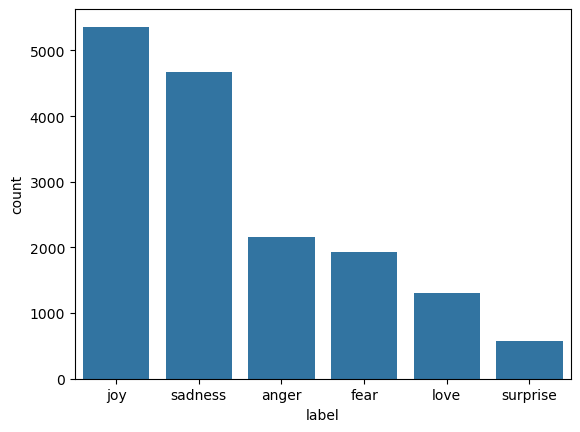

In [24]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [26]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


**4. Data Preprocessing - Using NLP**

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


**5. Shared Training Utilities**

In [33]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))
     

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**6. Phase 1 — Plain Foundational Models**

**6.1 Model 1 — Simple RNN**

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 85ms/step - accuracy: 0.1651 - loss: 1.9058 - val_accuracy: 0.1655 - val_loss: 1.7835
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - accuracy: 0.1654 - loss: 1.7997 - val_accuracy: 0.2555 - val_loss: 1.7598
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1838 - loss: 1.7786 - val_accuracy: 0.1510 - val_loss: 1.7950
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.1693 - loss: 1.7744 - val_accuracy: 0.0950 - val_loss: 1.8189
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.1631 - loss: 1.7682 - val_accuracy: 0.1345 - val_loss: 1.7985
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2555 - loss: 1.7598
RNN Loss: 1.7597980499267578
RNN Accuracy: 0.2554999887943268


**6.2 Model 2 — Standard LSTM**

In [44]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 191ms/step - accuracy: 0.1424 - loss: 1.7953 - val_accuracy: 0.0810 - val_loss: 1.8008
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 153ms/step - accuracy: 0.1619 - loss: 1.7941 - val_accuracy: 0.1315 - val_loss: 1.8091
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 157ms/step - accuracy: 0.1585 - loss: 1.7929 - val_accuracy: 0.0845 - val_loss: 1.8044
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.0810 - loss: 1.8008
LSTM Loss: 1.8007642030715942
LSTM Accuracy: 0.08100000023841858


**6.3 Model 3 — Standard GRU**

In [47]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 99s 184ms/step - accuracy: 0.1544 - loss: 1.7962 - val_accuracy: 0.1400 - val_loss: 1.7526
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 177ms/step - accuracy: 0.1519 - loss: 1.7951 - val_accuracy: 0.1120 - val_loss: 1.7825
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 96s 191ms/step - accuracy: 0.1644 - loss: 1.7945 - val_accuracy: 0.1160 - val_loss: 1.7978
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.1554 - loss: 1.7931 - val_accuracy: 0.1390 - val_loss: 1.7894
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1400 - loss: 1.7526
GRU Loss: 1.752645492553711
GRU Accuracy: 0.14000000059604645


**6.4 Phase 1 Ranking & Selection**

In [50]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.759798,0.2555
2,GRU,1.752645,0.1400
1,LSTM,1.800764,0.0810


**7. Phase 2 — Advanced Bidirectional GRU**


**7.1 Model 4 — Advanced Stacked Bidirectional GRU**

In [54]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train & Evaluate Advanced Bidirectional GRU**

In [57]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 332s 575ms/step - accuracy: 0.9131 - loss: 0.2513 - val_accuracy: 0.9160 - val_loss: 0.2441
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 305s 609ms/step - accuracy: 0.9427 - loss: 0.1578 - val_accuracy: 0.9135 - val_loss: 0.2720
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 310s 619ms/step - accuracy: 0.9582 - loss: 0.1142 - val_accuracy: 0.9190 - val_loss: 0.2475
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 304s 608ms/step - accuracy: 0.9679 - loss: 0.0914 - val_accuracy: 0.9175 - val_loss: 0.2962


In [59]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.9160 - loss: 0.2441
BiGRU Loss: 0.24414382874965668
BiGRU Accuracy: 0.9160000085830688


**8. Overall Evaluation & Bias Analysis**

**8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)**

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 267ms/step


<Axes: >

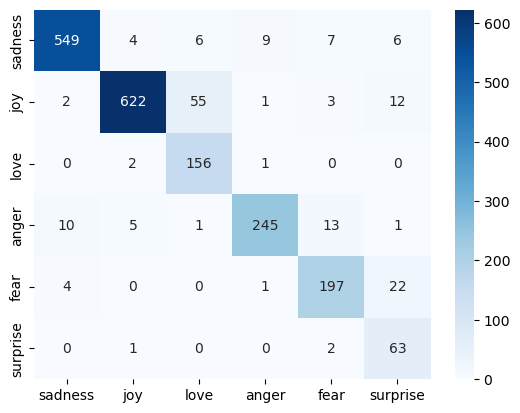

In [63]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

**9. Final Predictions**

In [66]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


**10. Save Model & Tokenizer**

In [69]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) 

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)